<a href="https://colab.research.google.com/github/hanmtay/IntroToAI_A2/blob/main/section3_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/hanmtay/IntroToAI_A2.git
%cd IntroToAI_A2

Cloning into 'IntroToAI_A2'...
remote: Enumerating objects: 3658, done.
remote: Counting objects: 100% (3658/3658), done.
remote: Compressing objects: 100% (2469/2469), done.
remote: Total 3658 (delta 1251), reused 3579 (delta 1188), pack-reused 0 (from 0)
Receiving objects: 100% (3658/3658), 2.15 MiB | 19.18 MiB/s, done.
Resolving deltas: 100% (1251/1251), done.
/content/IntroToAI_A2


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from scipy import stats
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

loading in dataset for training

In [3]:
train_df = pd.read_csv('TrainDataset1/all_features.csv', header=None)

task 3.1

Best Parameters: {'max_features': 4, 'n_estimators': 375}
Best CV Accuracy: 0.9338


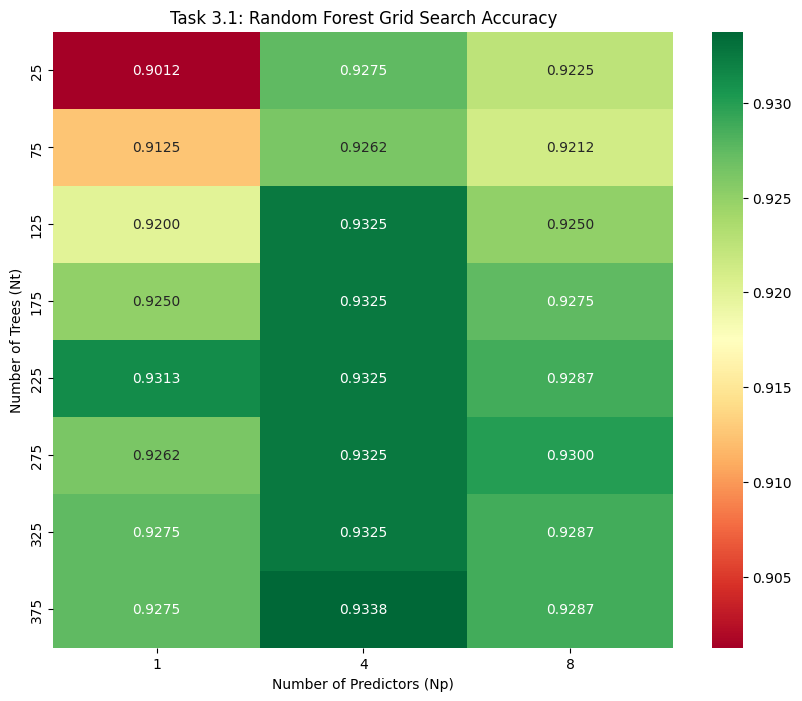

In [4]:
#column 0 is the Class Label (y)
#columns 2 to 17 are the numeric Features (X)
y = train_df.iloc[:, 0]
X = train_df.iloc[:, 2:]

#param_grid from: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
param_grid = {
    'n_estimators': [25, 75, 125, 175, 225, 275, 325, 375],
    'max_features': [1, 4, 8]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X, y)

results = pd.DataFrame(grid_search.cv_results_)
pivot_table = results.pivot(index='param_n_estimators', columns='param_max_features', values='mean_test_score')

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, fmt=".4f", cmap='RdYlGn')
plt.title('Task 3.1: Random Forest Grid Search Accuracy')
plt.xlabel('Number of Predictors (Np)')
plt.ylabel('Number of Trees (Nt)')
plt.savefig('task_3_1_heatmap.png')

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

task 3.2

In [7]:
#best parameter from above
best_n_estimators = 375
best_max_features = 4
seeds = range(42, 54)
accuracies = []

for seed in seeds:
    rf_best = RandomForestClassifier(
        n_estimators=best_n_estimators,
        max_features=best_max_features,
        random_state=seed
    )
    cv_scores = cross_val_score(rf_best, X, y, cv=5)
    accuracies.append(cv_scores.mean())

#mean and sd
mean_accuracy = np.mean(accuracies)
std_accuracy = np.std(accuracies)

print(f"12-run Mean Accuracy: {mean_accuracy:.4f}")
print(f"12-run Std Deviation: {std_accuracy:.4f}")

#t-test - chance is 1/8 so 0.125%
t_stat, p_value = stats.ttest_1samp(accuracies, 0.125)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("The model performs significantly better than chance (p < 0.05).")
else:
    print("The model performance is not significantly different from chance.")

12-run Mean Accuracy: 0.9334
12-run Std Deviation: 0.0007
T-statistic: 3604.3664
P-value: 9.4173e-35
The model performs significantly better than chance (p < 0.05).


task 3.3

Overall Test Accuracy:
0.9450

Classification Report (Precision, Recall/TPR, F1):
              precision    recall  f1-score   support

      banana       0.80      0.90      0.85        50
      cherry       0.96      0.86      0.91        50
    envelope       1.00      1.00      1.00        50
    golfclub       0.96      0.98      0.97        50
       lemon       0.98      0.96      0.97        50
      pencil       0.94      1.00      0.97        50
        tree       0.98      0.90      0.94        50
   wineglass       0.96      0.96      0.96        50

    accuracy                           0.94       400
   macro avg       0.95      0.95      0.95       400
weighted avg       0.95      0.94      0.95       400

False Positive Rate (FPR) per Class:
banana: 0.0314
cherry: 0.0057
envelope: 0.0000
golfclub: 0.0057
lemon: 0.0029
pencil: 0.0086
tree: 0.0029
wineglass: 0.0057


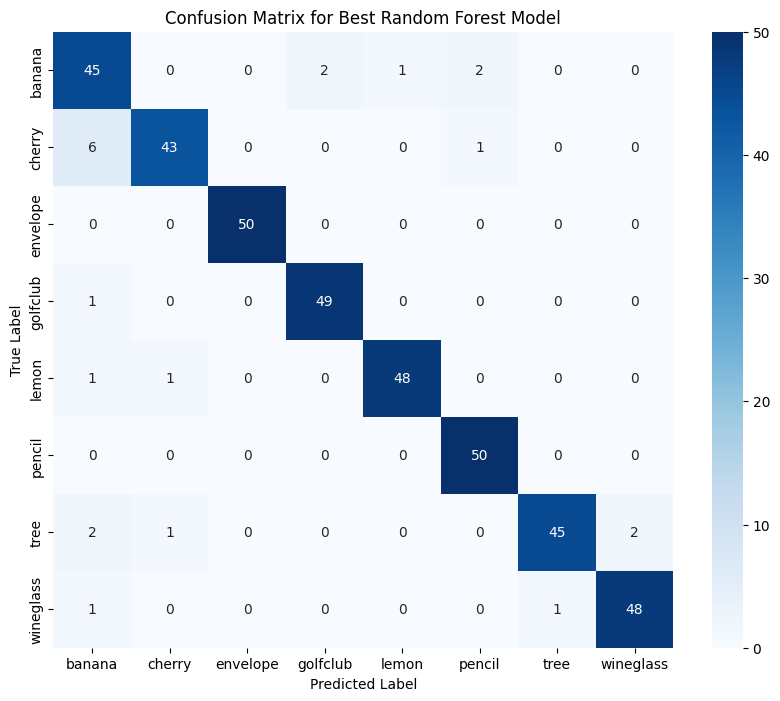

In [10]:
#loading in test data set
test_df = pd.read_csv('TestDataset1/all_features.csv', header=None)

#same as above
y_test = test_df.iloc[:, 0]
X_test = test_df.iloc[:, 2:]

#using training set from above
rf_final = RandomForestClassifier(n_estimators=375, max_features=4, random_state=42)
rf_final.fit(X, y)

y_pred = rf_final.predict(X_test)

print("Overall Test Accuracy:")
print(f"{accuracy_score(y_test, y_pred):.4f}\n")

print("Classification Report (Precision, Recall/TPR, F1):")
print(classification_report(y_test, y_pred))

#manaul fpr: https://stackoverflow.com/questions/59438262/false-positive-rate-in-confusion-matrix
cm = confusion_matrix(y_test, y_pred)
classes = sorted(y_test.unique())

print("False Positive Rate (FPR) per Class:")
for i in range(len(classes)):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    tn = cm.sum() - (fp + fn + tp)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    print(f"{classes[i]}: {fpr:.4f}")

# 6. Plot the Confusion Matrix Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix for Best Random Forest Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('task_3_3_confusion_matrix.png')
plt.show()